In [1]:
import numpy as np
from experiments.resnet_parameter_corr_between_worker import load_grad_files
import torch
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp
import gzip

In [2]:
train_attempt_count, worker_count, round_count, epoch_count, batch_count = 6, 2, 2, 30, 17
# train_attempt_count, worker_count, round_count, epoch_count, batch_count = 6, 2, 1, 2, 5

path_to_files = [f"exp_data/gradients_resnet/gradients_resnet_t{i}/"
                 for i in range(train_attempt_count)]

with open(path_to_files[-1] + f"_grad_namings.txt", "rb") as f:
    layer_names = f.read().decode("utf-8").replace("\r", '').split("\n")[:-1]

time_steps = np.array(np.meshgrid(range(round_count), range(epoch_count))).T.reshape(-1, 2)
base_model_dict = torch.load('exp_data/resnet18_svhn.pth', map_location='cpu')
base_model_dict = {k.replace('model.', ''): v.ravel().to('cuda')
                   for k, v in base_model_dict.items() if
                   k.replace('model.', '') in layer_names}

temp = {k: v.clone() for k, v in base_model_dict.items()}
base_model_dict = [base_model_dict, temp]

# worker_id, {layer_name}, element_id
train_attempt_model_dict = [
    {k: v.clone() for k, v in m_dict.items()}
    for m_dict in base_model_dict
]


In [3]:
attempt_target = 0
window_length = 5

sample_steps_windowed = np.array(np.meshgrid(
    range(0 + attempt_target, 1 + attempt_target),
    range(epoch_count),
    range(batch_count))).T.reshape(-1, 3)

sample_steps_windowed = [
    sample_steps_windowed[i:i + window_length]
    for i in range(
        0, len(sample_steps_windowed),
        int(np.ceil(batch_count / window_length) * window_length))
]

base_sample_dict = load_grad_files(sample_steps_windowed[len(sample_steps_windowed)-1],
    layer_names, path_to_files, 0, current_epoch=None, single_worker=True)

base_sample_dict = {
    k: np.array(base_sample_dict[k]).ravel()
    for k in layer_names
}

In [4]:
file_path = f'exp_data/distribution_shift_of_param_grad/hist_resnet18.pt.gz'
with gzip.open(file_path, "rb", compresslevel=1) as f:
    per_layer_hist_list = torch.load(f)

In [5]:
def get_dist_info_per_layer(sample_dict, bins):
    per_layer_hist = {k: None for k in layer_names}
    ks2s_v = {k: None for k in layer_names}
    for k in sample_dict.keys():
        temp = np.array(sample_dict[k]).ravel()
        ks2s_v[k] = ks_2samp(base_sample_dict[k], temp)

        temp = torch.tensor(temp, device='cuda').to(torch.float)
        per_layer_hist[k] = torch.histc(
            temp, bins=bins[k][2], min=bins[k][0], max=bins[k][1]).cpu().numpy()
        per_layer_hist[k] /= np.sum(len(base_sample_dict[k]))

    return per_layer_hist, ks2s_v

In [6]:
per_layer_hist_list = {k: [] for k in layer_names}
per_layer_ks2s_v_list = {k: [] for k in layer_names}
bins = {k: [np.min(base_sample_dict[k])*2, np.max(base_sample_dict[k])*2, 1000]
        for k in layer_names}

for curr_round in range(round_count):
    print(f"\nRound {curr_round} ------------")

    sample_steps_windowed = np.array(np.meshgrid(
        range(0 + attempt_target, 1 + attempt_target),
        range(epoch_count),
        range(batch_count))).T.reshape(-1, 3)
    sample_steps_windowed = [
        sample_steps_windowed[i:i + window_length]
        for i in range(
            0, len(sample_steps_windowed),
            int(np.ceil(batch_count / window_length) * window_length))]
    if len(sample_steps_windowed[-1]) != len(sample_steps_windowed[-2]):
        # remove the last element if it is not complete
        sample_steps_windowed = sample_steps_windowed[:-1]

    for i, sample_steps in enumerate(sample_steps_windowed):
        if (i + 1) % 6 == 0:
            print(f"  Sample {i + 1}/{len(sample_steps_windowed)}")
        # indexing: {layer_name}, sample_id, element_id
        sample_dict = load_grad_files(sample_steps,
                                      layer_names, path_to_files, curr_round,
                                      current_epoch=None,
                                      single_worker=True)  # <- note the single worker (one less dimension)
        hist, ks2s_v = get_dist_info_per_layer(sample_dict, bins)

        for k in sample_dict.keys():
            per_layer_hist_list[k].append(hist[k])
            per_layer_ks2s_v_list[k].append(ks2s_v[k])


Round 0 ------------
  Sample 6/26
  Sample 12/26
  Sample 18/26
  Sample 24/26

Round 1 ------------
  Sample 6/26
  Sample 12/26
  Sample 18/26
  Sample 24/26


In [7]:
file_path = f'exp_data/distribution_shift_of_param_grad/hist_resnet18.pt.gz'
with gzip.open(file_path, "wb", compresslevel=1) as f:
    torch.save(per_layer_hist_list,f)

MovieWriter imagemagick unavailable; using Pillow instead.


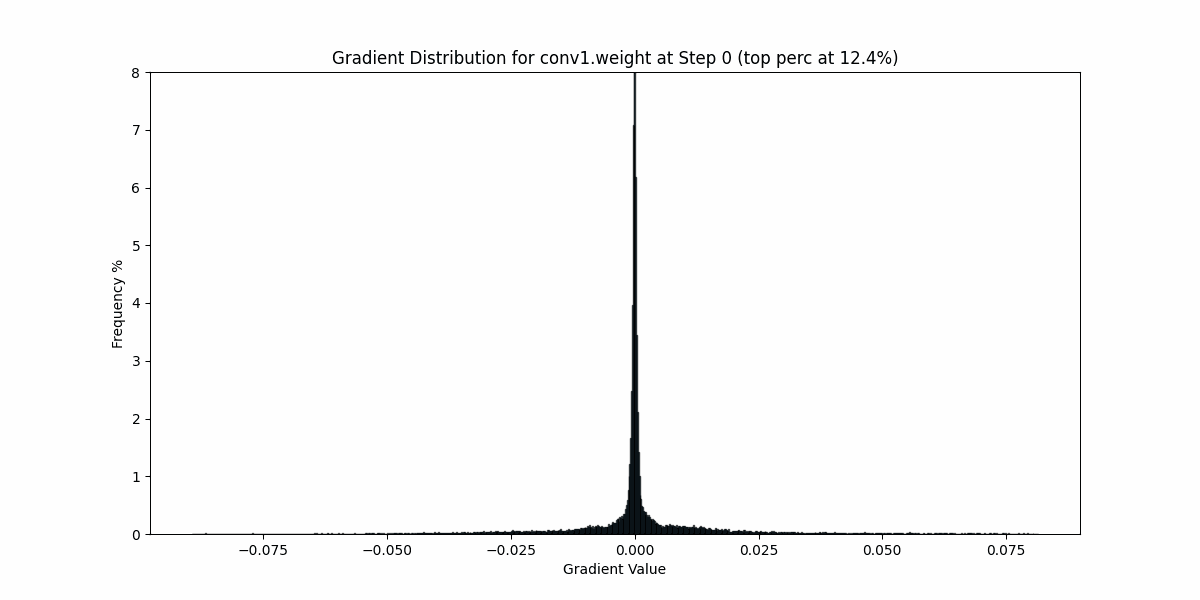

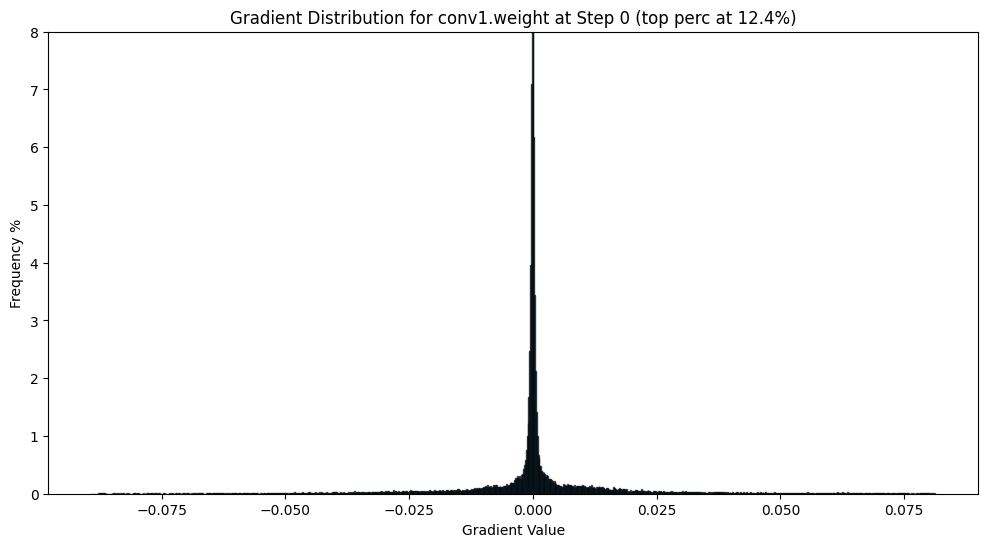

In [9]:
def plot_grad_distribution(per_layer_hist_list, t, k):
    hist_data = per_layer_hist_list[k][t]
    plt.figure(figsize=(12, 6))

    bin_width = (bins[k][1] - bins[k][0]) / bins[k][2]
    plt.bar(np.arange(bins[k][0], bins[k][1], bin_width), hist_data,
            width=bin_width, alpha=0.7, edgecolor='black',)

# plot_grad_distribution(per_layer_hist_list, 0, layer_names[0])

# make a gif
from matplotlib.animation import FuncAnimation
def animate_grad_distribution(per_layer_hist_list, k, ylim=False):
    fig, ax = plt.subplots(figsize=(12, 6))

    def update(frame):
        ax.clear()
        hist_data = per_layer_hist_list[k][frame]
        bin_width = (bins[k][1] - bins[k][0]) / bins[k][2]
        ax.bar(np.arange(bins[k][0], bins[k][1], bin_width), hist_data*100,
               width=bin_width, alpha=0.7, edgecolor='black')
        ax.set_title(f"Gradient Distribution for {k} at Step {frame} (top perc at {np.max(hist_data*100):.1f}%)")
        ax.set_xlabel("Gradient Value")
        ax.set_ylabel("Frequency %")
        if ylim:
            max_y = 1
        else:
            max_y = 8
        ax.set_ylim(0, max_y)
    ani = FuncAnimation(fig, update, frames=len(per_layer_hist_list[k]), repeat=True)
    return ani

ani = animate_grad_distribution(per_layer_hist_list, layer_names[0])
ani.save(f'exp_data/distribution_shift_of_param_grad/grad_dist_{layer_names[0]}.gif', writer='imagemagick', fps=3)

# open the gif via IPython display
from IPython.display import Image
Image(filename=f'exp_data/distribution_shift_of_param_grad/grad_dist_{layer_names[0]}.gif')

MovieWriter imagemagick unavailable; using Pillow instead.


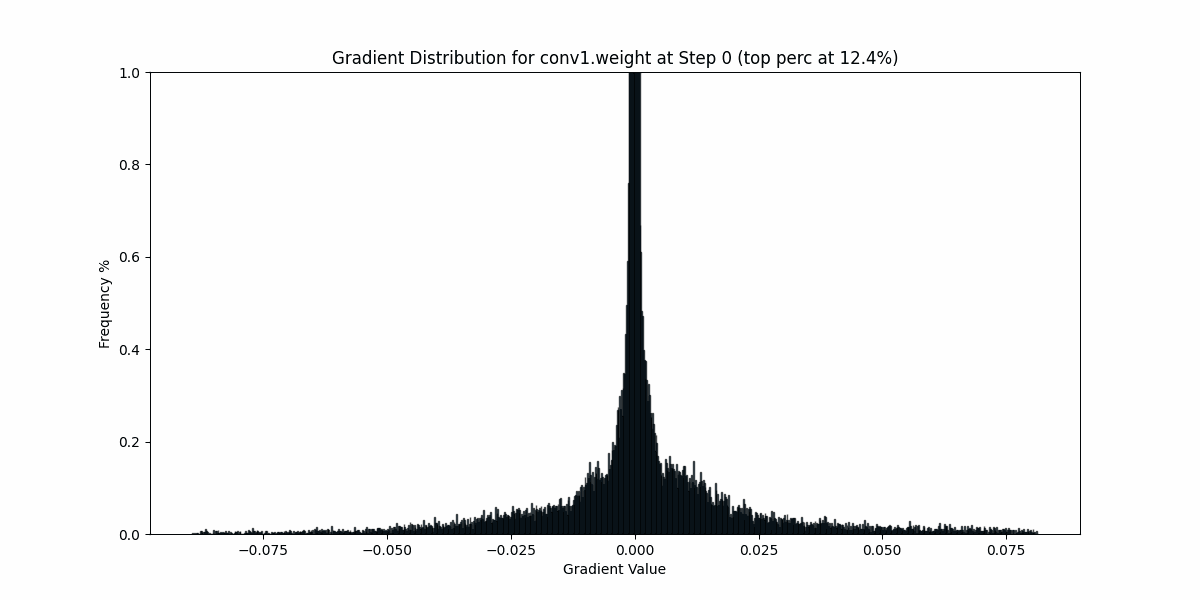

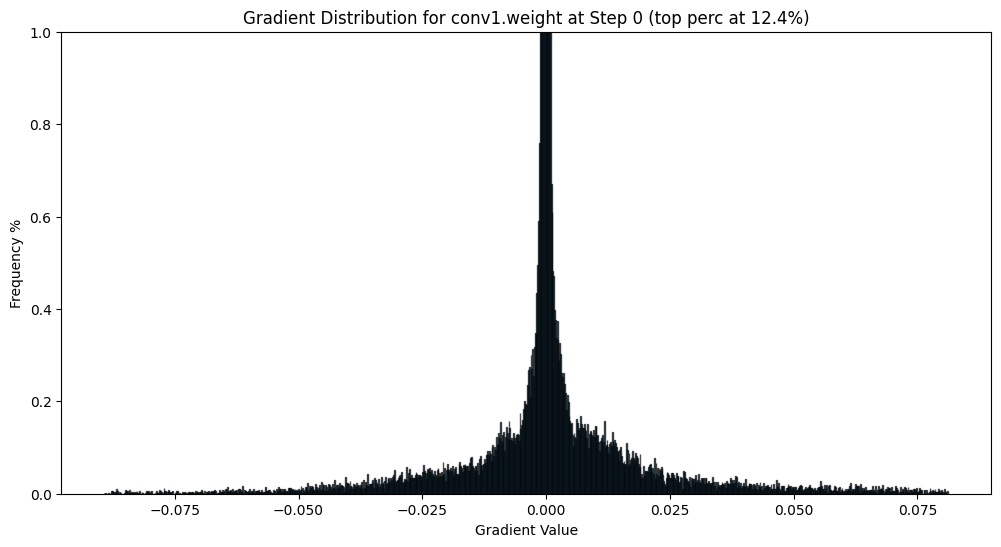

In [10]:
ani = animate_grad_distribution(per_layer_hist_list, layer_names[0], True)
ani.save(f'exp_data/distribution_shift_of_param_grad/grad_dist_ylim1_{layer_names[0]}.gif', writer='imagemagick', fps=3)
from IPython.display import Image
Image(filename=f'exp_data/distribution_shift_of_param_grad/grad_dist_ylim1_{layer_names[0]}.gif')

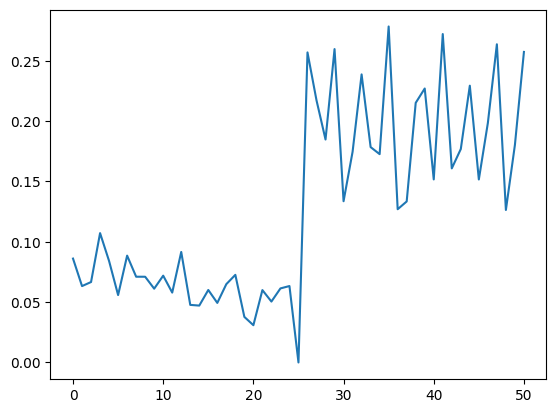

In [11]:
plt.plot([ks2s.statistic for ks2s in per_layer_ks2s_v_list[layer_names[0]]][:-1])

In [12]:
import numpy as np
from scipy.stats import entropy, wasserstein_distance, ks_2samp

def js_divergence(p, q):
    # Normalize the histograms to probability distributions
    p = np.array(p, dtype=np.float64)
    q = np.array(q, dtype=np.float64)
    p = p / np.sum(p)
    q = q / np.sum(q)
    m = 0.5 * (p + q)
    return 0.5 * (entropy(p, m) + entropy(q, m))

def compare_histograms(hist1, hist2, bins):
    hist1 = (hist1+1)/(np.sum(hist1)+len(hist1))
    hist2 = (hist2+1)/(np.sum(hist2)+len(hist2))

    # Calculate KL divergence (note: KL divergence is not symmetric)
    kl_div_1_2 = entropy(hist1, hist2)
    kl_div_2_1 = entropy(hist2, hist1)

    # Calculate JS divergence
    js_div = js_divergence(hist1, hist2)

    # Calculate the Wasserstein distance (requires bin centers)
    max_samples, min_samples, bin_counts = bins
    bin_width = (max_samples - min_samples) / bin_counts

    bin_edges = np.arange(min_samples, max_samples + bin_width, bin_width)
    # Ensure the last edge doesn't exceed max_samples due to potential floating point issues if necessary
    if bin_edges.shape[0] > bin_counts + 1 :
        bin_edges = bin_edges[:bin_counts+1]
    if bin_edges[-1] < max_samples and np.isclose(bin_edges[-1] + bin_width, max_samples) :
        bin_edges = np.append(bin_edges, max_samples)
    elif bin_edges[-1] > max_samples:
         bin_edges[-1] = max_samples

    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    wd = wasserstein_distance(bin_centers, bin_centers,
                              u_weights=hist1/np.sum(hist1),
                              v_weights=hist2/np.sum(hist2))

    # Optionally, perform a Kolmogorov-Smirnov test assuming you have raw samples.
    # For histograms, you might use the KS statistic on the cumulative sums.
    ks_stat = np.max(np.abs(np.cumsum(hist1/np.sum(hist1)) - np.cumsum(hist2/np.sum(hist2))))

    dist = np.sum(np.abs(hist1-hist2))/np.sum(np.abs(hist1))

    return [kl_div_1_2, kl_div_2_1, js_div, wd, ks_stat, dist]

    # return {
    #     "KL_divergence_1_to_2": kl_div_1_2,
    #     "KL_divergence_2_to_1": kl_div_2_1,
    #     "JS_divergence": js_div,
    #     "Wasserstein_distance": wd,
    #     "KS_statistic": ks_stat
    # }

base_hist = get_dist_info_per_layer(base_sample_dict, bins)[0]
compare_stat = np.array([
    compare_histograms(base_hist[layer_names[0]], hist, bins[layer_names[0]])
        for hist in per_layer_hist_list[layer_names[0]]
]).T

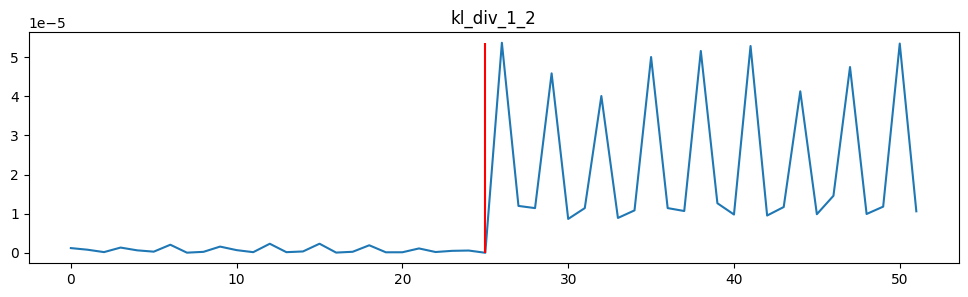

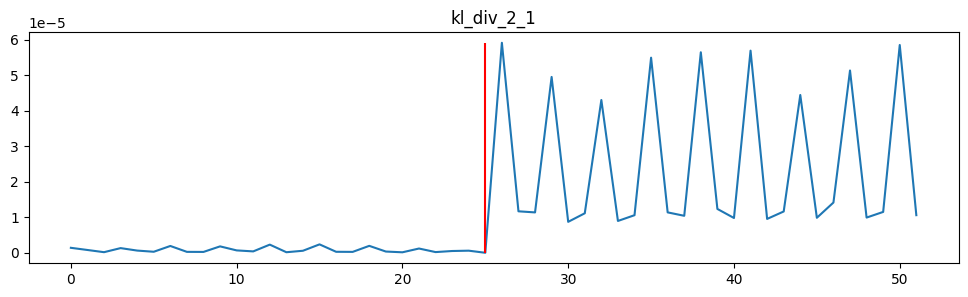

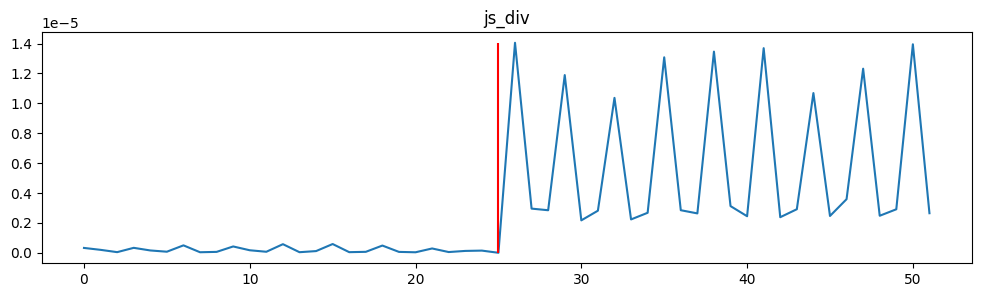

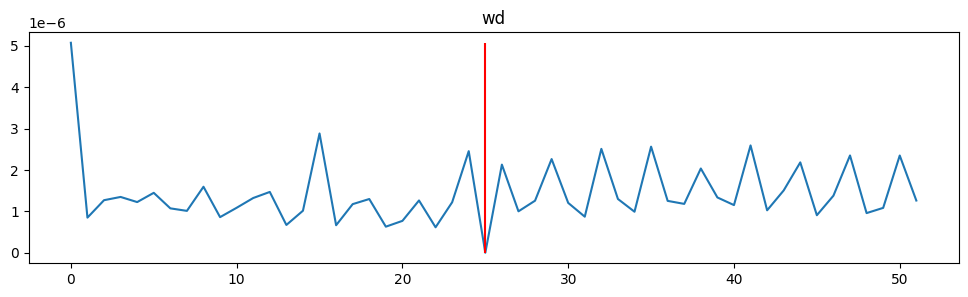

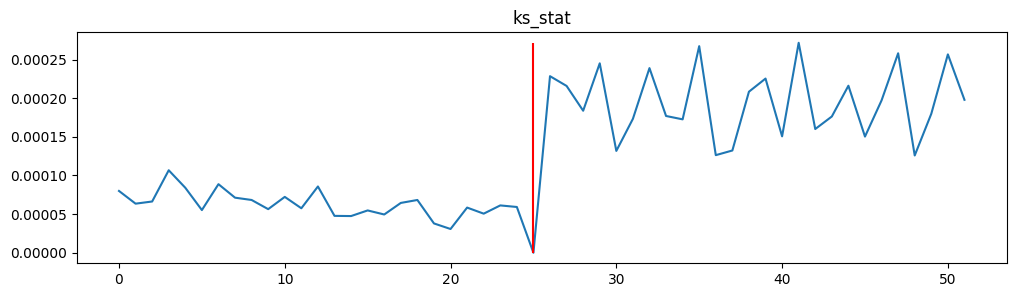

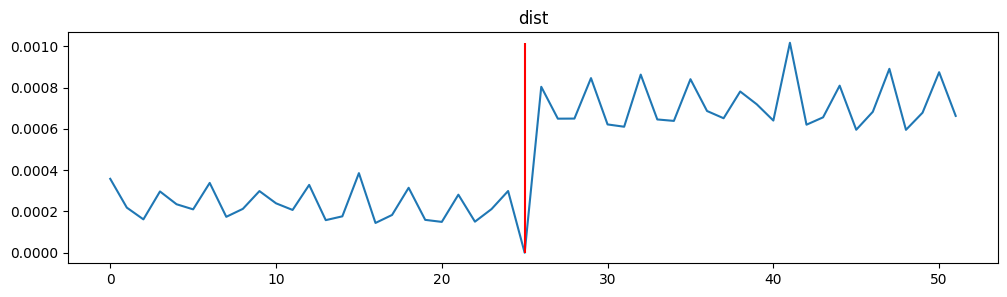

In [13]:
for i, stat_vector in enumerate(compare_stat):
    plt.figure(figsize=(12, 3))
    plt.plot(stat_vector)
    plt.vlines(len(sample_steps_windowed)-1, 0, np.max(stat_vector),colors='red')
    plt.title(f"{['kl_div_1_2', 'kl_div_2_1', 'js_div', 'wd', 'ks_stat', 'dist'][i]}")
    plt.show()

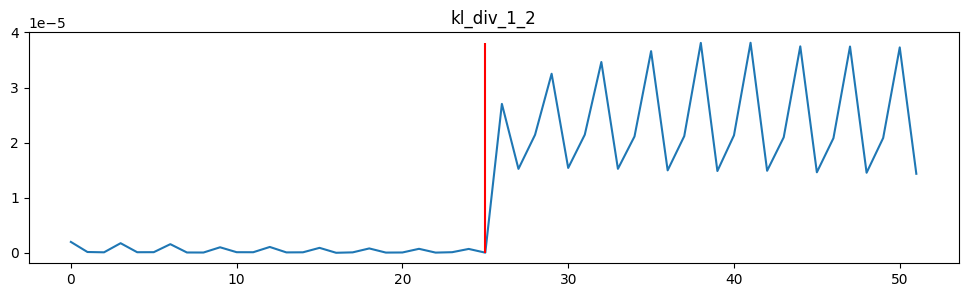

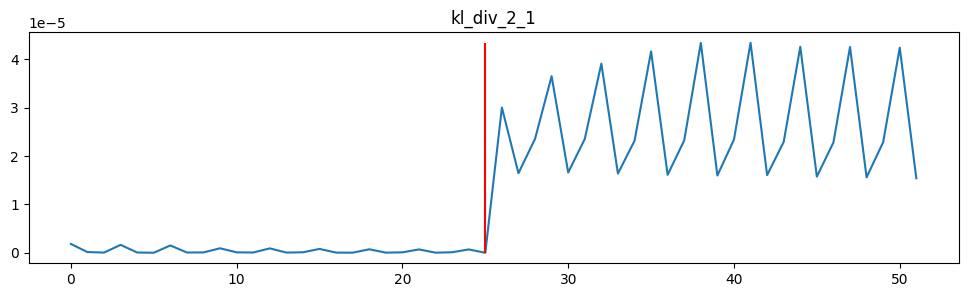

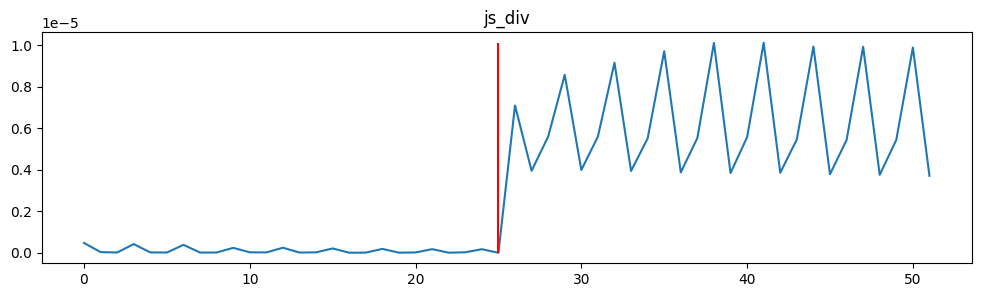

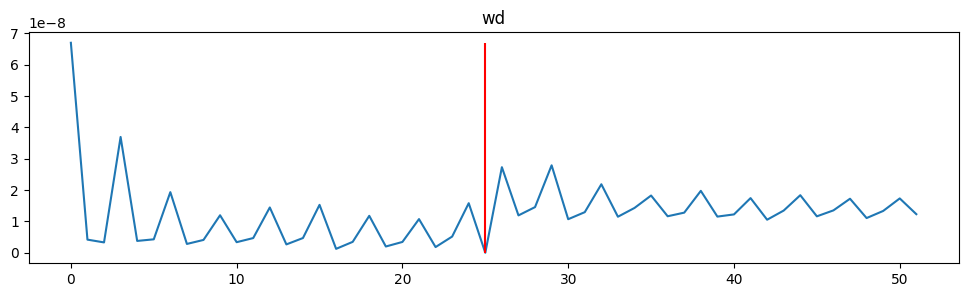

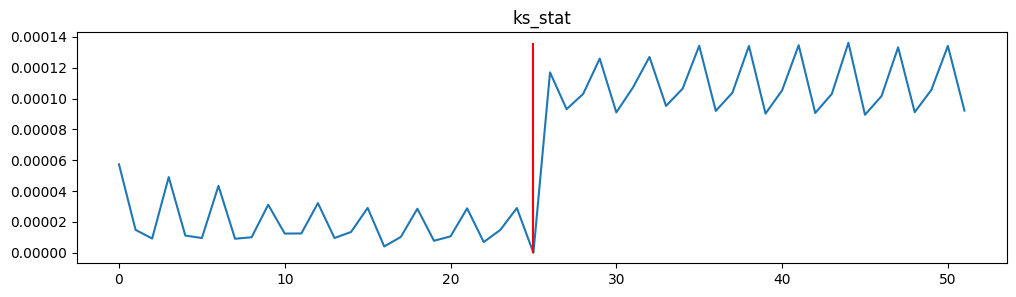

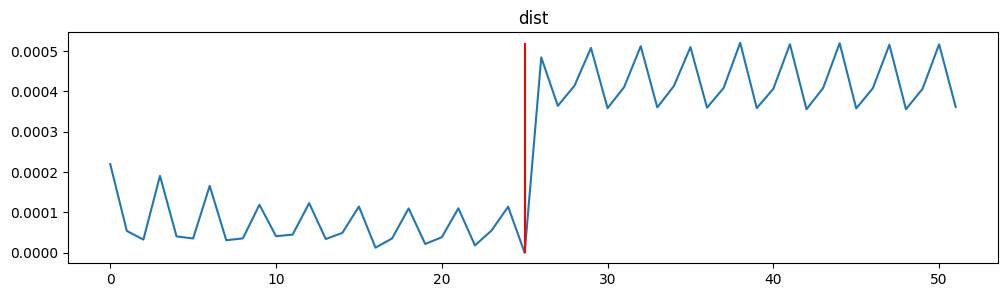

In [14]:
base_hist = get_dist_info_per_layer(base_sample_dict, bins)[0]
compare_stat = np.array([
    compare_histograms(base_hist[layer_names[0]], hist, bins[layer_names[0]])
        for hist in per_layer_hist_list[layer_names[0]]
]).T*0
total_param_count = sum([len(base_sample_dict[k]) for k in layer_names])
for k in layer_names:
    compare_stat += np.array([
        compare_histograms(base_hist[k], hist, bins[k])
            for hist in per_layer_hist_list[k]
    ]).T * len(base_sample_dict[k])/total_param_count
for i, stat_vector in enumerate(compare_stat):
    plt.figure(figsize=(12, 3))
    plt.plot(stat_vector)
    plt.vlines(len(sample_steps_windowed)-1, 0, np.max(stat_vector),colors='red')
    plt.title(f"{['kl_div_1_2', 'kl_div_2_1', 'js_div', 'wd', 'ks_stat', 'dist'][i]}")
    plt.show()